# Customer Support Ticket Intelligence Platform
## Phase 4: Embedding Studies — From Sparse to Dense Representations

**Objective**: Build our first trainable deep learning model (MODEL-v1: Bag of Embeddings) and run a systematic embedding dimension sweep to understand how dense word representations capture semantic meaning.

**What we'll learn**:
1. Why one-hot encoding is impractical for large vocabularies
2. How `nn.Embedding` works as a learnable lookup table
3. Why masked average pooling is critical when using padding
4. How embedding dimensionality affects classification performance

**Experiments**: EXP-01 (50d) → EXP-02 (100d) → EXP-03 (200d) → EXP-04 (300d)

In [ ]:
# ==============================================================================
# ENVIRONMENT SETUP & DEVICE CONFIGURATION BOOTSTRAP CELL
# ==============================================================================
import os
import sys
from pathlib import Path

# 1. Detect Environment
IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    print("Detected Environment: Google Colab")
    
    # Mount Google Drive if requested (uncomment if needed)
    # from google.colab import drive
    # drive.mount('/content/drive')
    
    # Clone the repository if not present
    repo_name = "customer-support-ticket-intelligence-platform"
    repo_url = f"https://github.com/ikartiksavaliya/{repo_name}.git"
    target_dir = f"/content/{repo_name}"
    
    if not os.path.exists(target_dir):
        print(f"Cloning repository {repo_url}...")
        import subprocess
        subprocess.run(["git", "clone", repo_url, target_dir], check=True)
    
    # Change working directory to the repository root
    os.chdir(target_dir)
    
    # Add project root to sys.path
    if target_dir not in sys.path:
        sys.path.insert(0, target_dir)
        
    # Install requirements
    print("Installing requirements.txt and package in editable mode...")
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-e", "."], check=True)
else:
    print("Detected Environment: Local Machine / VS Code")
    # Add project root to sys.path by climbing up directories
    ROOT = Path.cwd()
    while ROOT != ROOT.parent and not (ROOT / "src").exists():
        ROOT = ROOT.parent
    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))
    os.chdir(str(ROOT))

# 2. Verify Imports & Configure Device
import torch
try:
    from src.utils import get_device, set_seed
    from src.preprocessing import clean_text
    from src.vocabulary import Vocabulary
    from src.dataset import TicketDataset
    print("✅ Project modules successfully imported!")
except ImportError as e:
    print(f"❌ Failed to import project modules: {e}")
    raise e

# Initialize seed for reproducibility
set_seed(42)

# Get compute device
device, device_type, device_name = get_device()


---
### Section 1: Environment Setup & Data Loading

In [2]:
import sys, os, json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from src.utils import set_seed, get_device, compute_class_weights
from src.preprocessing import clean_text, tokenize
from src.vocabulary import Vocabulary
from src.dataset import TicketDataset
from src.models import BagOfEmbeddings
from src.training import train_model,evaluate
from src.evaluation import (
    compute_metrics, print_classification_report,
    plot_confusion_matrix, plot_training_curves
)

# Reproducibility
set_seed(42)
device, _, _ = get_device()
print(device)
print(f"PyTorch version: {torch.__version__}")

ModuleNotFoundError: No module named 'src'

In [ ]:
# Load pre-built artifacts from Phase 3
vocab = Vocabulary.load("../outputs/vocab.json")
with open("../outputs/label_encoder.json", "r") as f:
    label_encoder = json.load(f)

# Inverse mapping for readable labels
idx2label = {v: k for k, v in label_encoder.items()}
label_names = [idx2label[i] for i in range(len(label_encoder))]

print(f"Vocabulary size : {len(vocab):,}")
print(f"Number of classes: {len(label_encoder)}")
print(f"Classes: {list(label_encoder.keys())[:5]} ... ({len(label_encoder)} total)")

Vocabulary size : 23,262
Number of classes: 18
Classes: ['Bank account or service', 'Checking or savings account', 'Consumer Loan', 'Credit card', 'Credit card or prepaid card'] ... (18 total)


In [ ]:
# Load stratified train/val/test splits from Phase 3
train_df = pd.read_csv("../data/splits/train.csv")
val_df   = pd.read_csv("../data/splits/val.csv")
test_df  = pd.read_csv("../data/splits/test.csv")

print(f"Train : {len(train_df):>7,} samples")
print(f"Val   : {len(val_df):>7,} samples")
print(f"Test  : {len(test_df):>7,} samples")
print(f"Total : {len(train_df)+len(val_df)+len(test_df):>7,} samples")

Train : 160,000 samples
Val   :  20,000 samples
Test  :  20,000 samples
Total : 200,000 samples


---
### Section 2: Create PyTorch DataLoaders

In [ ]:
MAX_LEN = 256
BATCH_SIZE = 64

train_ds = TicketDataset(train_df, vocab, label_encoder, max_len=MAX_LEN)
val_ds   = TicketDataset(val_df,   vocab, label_encoder, max_len=MAX_LEN)
test_ds  = TicketDataset(test_df,  vocab, label_encoder, max_len=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Sanity check: inspect one batch
sample_ids, sample_labels = next(iter(train_loader))
print(f"Batch input_ids shape : {sample_ids.shape}")
print(f"Batch labels shape    : {sample_labels.shape}")
print(f"Label distribution in batch: {dict(zip(*np.unique(sample_labels.numpy(), return_counts=True)))}")

Batch input_ids shape : torch.Size([64, 256])
Batch labels shape    : torch.Size([64])
Label distribution in batch: {np.int64(0): np.int64(2), np.int64(1): np.int64(4), np.int64(2): np.int64(2), np.int64(3): np.int64(1), np.int64(4): np.int64(2), np.int64(5): np.int64(6), np.int64(6): np.int64(19), np.int64(7): np.int64(14), np.int64(8): np.int64(1), np.int64(9): np.int64(1), np.int64(10): np.int64(8), np.int64(13): np.int64(2), np.int64(15): np.int64(2)}


---
### Section 3: Theory — One-Hot vs Dense Embeddings

#### One-Hot Encoding (Sparse Representation)
Each word is represented as a vector of size $V$ (vocabulary size) with a single `1` and all other entries `0`.

$$\text{one\_hot}(\text{"mortgage"}) = [0, 0, ..., 1, ..., 0, 0] \in \mathbb{R}^{V}$$

**Problems with One-Hot:**
1. **Dimensionality**: With $V = 23{,}262$, each word requires a 23,262-dimensional vector — extremely wasteful.
2. **No Semantics**: `cosine_similarity(one_hot("mortgage"), one_hot("loan")) = 0`. Every word is equidistant from every other word — the representation contains zero semantic information.
3. **Memory**: A single batch of 64 sequences × 256 tokens × 23,262 dims = **382 million** float values.

#### Dense Embeddings (Learned Representation)
Each word is represented as a compact $d$-dimensional vector (e.g., $d=50$) that is **learned during training**.

$$E \in \mathbb{R}^{V \times d}, \quad e_{\text{mortgage}} = E[\text{idx}_{\text{mortgage}}] \in \mathbb{R}^d$$

**Advantages:**
1. **Compact**: Same batch needs only 64 × 256 × 50 = **819,200** float values (466× smaller).
2. **Semantic**: Training pushes related words closer together — `"mortgage"` and `"loan"` will have similar vectors.
3. **Learnable**: The embedding matrix $E$ is a trainable parameter updated via backpropagation.

In [ ]:
# Memory comparison: One-Hot vs Dense Embeddings
V = len(vocab)

print("=" * 60)
print("MEMORY COMPARISON: One-Hot vs Dense Embeddings")
print("=" * 60)

for emb_dim in [50, 100, 200, 300]:
    onehot_bytes = BATCH_SIZE * MAX_LEN * V * 4  # float32
    dense_bytes  = BATCH_SIZE * MAX_LEN * emb_dim * 4
    ratio = onehot_bytes / dense_bytes
    
    print(f"\nEmbedding Dim = {emb_dim}:")
    print(f"  One-Hot batch memory : {onehot_bytes / 1e9:.2f} GB")
    print(f"  Dense batch memory   : {dense_bytes / 1e6:.2f} MB")
    print(f"  Compression ratio    : {ratio:.0f}×")

MEMORY COMPARISON: One-Hot vs Dense Embeddings

Embedding Dim = 50:
  One-Hot batch memory : 1.52 GB
  Dense batch memory   : 3.28 MB
  Compression ratio    : 465×

Embedding Dim = 100:
  One-Hot batch memory : 1.52 GB
  Dense batch memory   : 6.55 MB
  Compression ratio    : 233×

Embedding Dim = 200:
  One-Hot batch memory : 1.52 GB
  Dense batch memory   : 13.11 MB
  Compression ratio    : 116×

Embedding Dim = 300:
  One-Hot batch memory : 1.52 GB
  Dense batch memory   : 19.66 MB
  Compression ratio    : 78×


---
### Section 4: Theory — `nn.Embedding` as a Lookup Table

PyTorch's `nn.Embedding(num_embeddings, embedding_dim)` is simply a **weight matrix** $E \in \mathbb{R}^{V \times d}$ that maps integer indices to dense vectors via array indexing:

$$\text{nn.Embedding}(w_t) = E[w_t] \in \mathbb{R}^d$$

This is **mathematically equivalent** to multiplying a one-hot vector by $E$:
$$e_t = E^T \cdot \text{one\_hot}(w_t)$$

But the implementation uses direct indexing (O(1) per token) instead of matrix multiplication (O(V·d) per token).

**Key parameter: `padding_idx=0`**
- Ensures the embedding at index 0 (our `<PAD>` token) is always the zero vector.
- Gradients are NOT computed for this index — padding never influences learning.

In [ ]:
# Demonstrate nn.Embedding with a tiny example
set_seed(42)
tiny_emb = nn.Embedding(num_embeddings=5, embedding_dim=3, padding_idx=0)

print("Embedding weight matrix (5 words × 3 dims):")
print(tiny_emb.weight.data)
print()

# Lookup specific words
tokens = torch.tensor([1, 3, 0, 2])  # word indices, 0 = PAD
result = tiny_emb(tokens)
print(f"Input indices: {tokens.tolist()}")
print(f"Lookup result (4 × 3):\n{result.data}")
print(f"\nNote: index 0 (PAD) always returns zeros: {result[2].tolist()}")

Embedding weight matrix (5 words × 3 dims):
tensor([[ 0.0000,  0.0000,  0.0000],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617],
        [ 0.2674,  0.5349,  0.8094],
        [ 1.1103, -1.6898, -0.9890]])

Input indices: [1, 3, 0, 2]
Lookup result (4 × 3):
tensor([[ 0.2303, -1.1229, -0.1863],
        [ 0.2674,  0.5349,  0.8094],
        [ 0.0000,  0.0000,  0.0000],
        [ 2.2082, -0.6380,  0.4617]])

Note: index 0 (PAD) always returns zeros: [0.0, 0.0, 0.0]


---
### Section 5: Build MODEL-v1 — Bag of Embeddings (BoE) Classifier

The Bag of Embeddings model is our **sequence-agnostic deep learning baseline**. It:
1. Embeds each token into a dense vector
2. Averages all non-PAD embeddings into a single document vector  
3. Projects through a linear layer to class logits

This model completely **ignores word order** — it's the deep learning equivalent of Bag-of-Words. Any future RNN/LSTM that scores lower than BoE is broken.

In [ ]:
# Instantiate BoE with 50d embeddings
model = BagOfEmbeddings(
    vocab_size=len(vocab),
    embedding_dim=50,
    num_classes=len(label_encoder),
)
model = model.to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

BagOfEmbeddings(
  (embedding): Embedding(23262, 50, padding_idx=0)
  (fc): Linear(in_features=50, out_features=18, bias=True)
)

Total parameters: 1,164,018
Trainable params: 1,164,018


---
### Section 6: Why Masked Average Pooling Matters

Without masking, PAD tokens (index 0, zero vectors) are counted in the average denominator. For a 20-token sequence padded to 256, the mean is divided by 256 instead of 20 — diluting the real signal by **12.8×**.

In [ ]:
# Demonstrate masked vs unmasked pooling
demo_input = torch.tensor([[5, 12, 8, 0, 0, 0, 0, 0]], device=device)  # 3 real + 5 PAD
demo_emb = model.embedding(demo_input)  # (1, 8, 50)

# Unmasked (WRONG): average includes PAD zeros
unmasked_avg = demo_emb.mean(dim=1)  # divides by 8 

# Masked (CORRECT): average excludes PAD
mask = (demo_input != 0).unsqueeze(-1).float()
masked_avg = (demo_emb * mask).sum(dim=1) / mask.sum(dim=1)

print(f"Real tokens  : 3 out of 8")
print(f"Unmasked norm: {unmasked_avg.norm().item():.4f}  (diluted by PAD)")
print(f"Masked norm  : {masked_avg.norm().item():.4f}  (correct magnitude)")
print(f"Ratio        : {masked_avg.norm().item() / unmasked_avg.norm().item():.2f}× stronger signal")

Real tokens  : 3 out of 8
Unmasked norm: 1.4771  (diluted by PAD)
Masked norm  : 3.9390  (correct magnitude)
Ratio        : 2.67× stronger signal


---
### Section 7: Training Setup — Class Weights & Optimizer

In [ ]:
# Compute class weights for imbalanced CFPB data
class_weights = compute_class_weights(label_encoder, train_df)
print("Class weights (inverse frequency):")
for name, idx in sorted(label_encoder.items(), key=lambda x: x[1]):
    print(f"  [{idx:2d}] {name:55s} → weight: {class_weights[idx]:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
print(f"\nLoss function: CrossEntropyLoss with class weights")

Class weights (inverse frequency):
  [ 0] Bank account or service                                 → weight: 1.3728
  [ 1] Checking or savings account                             → weight: 1.5862
  [ 2] Consumer Loan                                           → weight: 2.1601
  [ 3] Credit card                                             → weight: 1.0873
  [ 4] Credit card or prepaid card                             → weight: 0.9580
  [ 5] Credit reporting                                        → weight: 0.6838
  [ 6] Credit reporting, credit repair services, or other personal consumer reports → weight: 0.2535
  [ 7] Debt collection                                         → weight: 0.2419
  [ 8] Money transfer, virtual currency, or money service      → weight: 3.7380
  [ 9] Money transfers                                         → weight: 13.6333
  [10] Mortgage                                                → weight: 0.3852
  [11] Other financial service                                 

---
### Section 8: Train BoE (50d) — EXP-01

Our first full training run! We use Adam optimizer with lr=1e-3 for 10 epochs.

In [ ]:
set_seed(42)
EPOCHS = 10

model_50d = BagOfEmbeddings(len(vocab), embedding_dim=50, num_classes=len(label_encoder)).to(device)
optimizer = torch.optim.Adam(model_50d.parameters(), lr=1e-3)

print(f"Training BoE (50d) for {EPOCHS} epochs...")
print(f"Parameters: {sum(p.numel() for p in model_50d.parameters()):,}")
print()

history_50d = train_model(
    model=model_50d,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    checkpoint_path="../outputs/boe_50d_best.pt",
)

Training BoE (50d) for 10 epochs...
Parameters: 1,164,018

  Epoch |  Train Loss |  Val Loss |  Val F1 |   Time
-------------------------------------------------------
  [ 1/10] |      2.3069 |    1.8445 | 0.3624 | 104.4s ✓
  [ 2/10] |      1.6332 |    1.5163 | 0.4126 |  81.1s ✓
  [ 3/10] |      1.3949 |    1.3888 | 0.4425 |  80.0s ✓
  [ 4/10] |      1.2708 |    1.3183 | 0.4669 |  86.6s ✓
  [ 5/10] |      1.1838 |    1.2722 | 0.4767 |  87.1s ✓
  [ 6/10] |      1.1111 |    1.2415 | 0.4883 |  86.7s ✓
  [ 7/10] |      1.0526 |    1.2160 | 0.4920 |  87.3s ✓
  [ 8/10] |      1.0014 |    1.2024 | 0.5014 | 107.4s ✓
  [ 9/10] |      0.9519 |    1.1880 | 0.5060 | 115.2s ✓
  [10/10] |      0.9127 |    1.1793 | 0.5062 | 118.9s ✓
-------------------------------------------------------
Best Val F1: 0.5062


---
### Section 9: Evaluate BoE (50d) — Classification Report & Confusion Matrix

Training curves saved to: ../outputs/boe_50d_curves.png


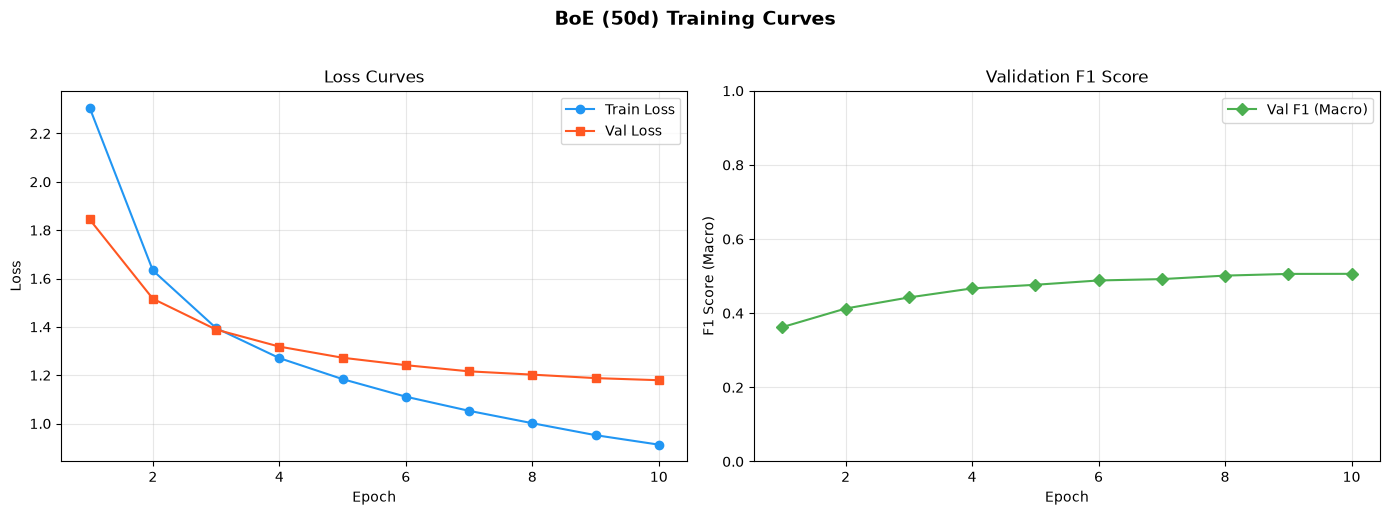

In [14]:
# Plot training curves
plot_training_curves(history_50d, title="BoE (50d) Training Curves", save_path="../outputs/boe_50d_curves.png")

In [15]:
# Evaluate on validation set
val_loss, val_preds, val_labels = evaluate(
    model_50d, val_loader, criterion, device
)

metrics_50d = compute_metrics(val_labels, val_preds)
print("\nValidation Metrics (BoE 50d):")
for k, v in metrics_50d.items():
    print(f"  {k:20s}: {v:.4f}")


Validation Metrics (BoE 50d):
  accuracy            : 0.6781
  f1_macro            : 0.5062
  precision_macro     : 0.4723
  recall_macro        : 0.5862


In [16]:
# Full classification report
print("\nPer-Class Classification Report:")
print_classification_report(val_labels, val_preds, label_names)


Per-Class Classification Report:
                                                                              precision    recall  f1-score   support

                                                     Bank account or service     0.5355    0.5871    0.5601       809
                                                 Checking or savings account     0.5726    0.5849    0.5787       701
                                                               Consumer Loan     0.3665    0.5010    0.4233       515
                                                                 Credit card     0.5073    0.5802    0.5413      1022
                                                 Credit card or prepaid card     0.5424    0.5569    0.5496      1160
                                                            Credit reporting     0.4958    0.6585    0.5657      1625
Credit reporting, credit repair services, or other personal consumer reports     0.7884    0.5645    0.6579      4383
                     

In [1]:
# Confusion matrix
plot_confusion_matrix(val_labels, val_preds, label_names, save_path="../outputs/boe_50d_confusion.png")

NameError: name 'plot_confusion_matrix' is not defined

---
### Section 10: Embedding Dimension Sweep — EXP-01 to EXP-04

Now we systematically compare embedding dimensions: **50, 100, 200, 300**.

This sweep answers: *Does increasing embedding dimensionality improve classification performance, and at what cost in parameters and training time?*

In [ ]:
EMBEDDING_DIMS = [50, 100, 200, 300]
EXP_IDS = ["EXP-01", "EXP-02", "EXP-03", "EXP-04"]
EPOCHS = 10

sweep_results = []

for exp_id, emb_dim in zip(EXP_IDS, EMBEDDING_DIMS):
    print(f"\n{'='*60}")
    print(f"{exp_id}: Training BoE (embedding_dim={emb_dim})")
    print(f"{'='*60}")
    
    set_seed(42)
    
    model = BagOfEmbeddings(
        vocab_size=len(vocab),
        embedding_dim=emb_dim,
        num_classes=len(label_encoder),
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    param_count = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {param_count:,}")
    
    start_time = time.time()
    
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=EPOCHS,
        checkpoint_path=f"../outputs/boe_{emb_dim}d_best.pt",
    )
    
    total_time = time.time() - start_time
    
    # Evaluate
    val_loss, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
    metrics = compute_metrics(val_labels, val_preds)
    
    sweep_results.append({
        "exp_id": exp_id,
        "embedding_dim": emb_dim,
        "param_count": param_count,
        "best_val_f1": max(history["val_f1"]),
        "final_val_f1": metrics["f1_macro"],
        "final_val_loss": val_loss,
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "total_time_sec": total_time,
        "avg_epoch_time": np.mean(history["epoch_time"]),
        "history": history,
    })

print(f"\n\n{'='*60}")
print("SWEEP COMPLETE!")
print(f"{'='*60}")


EXP-01: Training BoE (embedding_dim=50)
Parameters: 1,164,018
  Epoch |  Train Loss |  Val Loss |  Val F1 |   Time
-------------------------------------------------------


  [ 1/10] |      2.3069 |    1.8445 | 0.3624 | 135.7s ✓
  [ 2/10] |      1.6332 |    1.5163 | 0.4126 | 162.3s ✓
  [ 3/10] |      1.3949 |    1.3888 | 0.4425 | 152.3s ✓
  [ 4/10] |      1.2708 |    1.3183 | 0.4669 | 185.4s ✓
  [ 5/10] |      1.1838 |    1.2722 | 0.4767 | 147.5s ✓
  [ 6/10] |      1.1111 |    1.2415 | 0.4883 |  81.4s ✓
  [ 7/10] |      1.0526 |    1.2160 | 0.4920 | 104.5s ✓
  [ 8/10] |      1.0014 |    1.2024 | 0.5014 |  99.4s ✓
  [ 9/10] |      0.9519 |    1.1880 | 0.5060 |  67.3s ✓
  [10/10] |      0.9127 |    1.1793 | 0.5062 |  79.6s ✓
-------------------------------------------------------
Best Val F1: 0.5062

EXP-02: Training BoE (embedding_dim=100)
Parameters: 2,328,018
  Epoch |  Train Loss |  Val Loss |  Val F1 |   Time
-------------------------------------------------------


---
### Section 11: Sweep Results — Comparison Table & Visualisation

In [ ]:
# Create comparison DataFrame
results_df = pd.DataFrame([{
    "Experiment": r["exp_id"],
    "Emb Dim": r["embedding_dim"],
    "Parameters": f"{r['param_count']:,}",
    "Val F1 (Macro)": f"{r['best_val_f1']:.4f}",
    "Accuracy": f"{r['accuracy']:.4f}",
    "Precision": f"{r['precision_macro']:.4f}",
    "Recall": f"{r['recall_macro']:.4f}",
    "Train Time (s)": f"{r['total_time_sec']:.1f}",
} for r in sweep_results])

print("\nEmbedding Dimension Sweep Results:")
print("=" * 100)
print(results_df.to_string(index=False))

In [ ]:
# Visualise sweep results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dims = [r["embedding_dim"] for r in sweep_results]
f1s  = [r["best_val_f1"] for r in sweep_results]
params = [r["param_count"] for r in sweep_results]
times = [r["total_time_sec"] for r in sweep_results]

# F1 vs Dim
axes[0].bar(range(len(dims)), f1s, color=["#2196F3","#4CAF50","#FF9800","#F44336"], width=0.6)
axes[0].set_xticks(range(len(dims)))
axes[0].set_xticklabels([f"{d}d" for d in dims])
axes[0].set_ylabel("Macro F1 Score")
axes[0].set_title("F1 Score vs Embedding Dimension")
axes[0].set_ylim(0, max(f1s)*1.15)
for i, v in enumerate(f1s):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=10, fontweight='bold')

# Params vs Dim
axes[1].bar(range(len(dims)), [p/1e6 for p in params], color=["#2196F3","#4CAF50","#FF9800","#F44336"], width=0.6)
axes[1].set_xticks(range(len(dims)))
axes[1].set_xticklabels([f"{d}d" for d in dims])
axes[1].set_ylabel("Parameters (Millions)")
axes[1].set_title("Parameter Count vs Embedding Dimension")

# Time vs Dim
axes[2].bar(range(len(dims)), times, color=["#2196F3","#4CAF50","#FF9800","#F44336"], width=0.6)
axes[2].set_xticks(range(len(dims)))
axes[2].set_xticklabels([f"{d}d" for d in dims])
axes[2].set_ylabel("Total Training Time (seconds)")
axes[2].set_title("Training Time vs Embedding Dimension")

plt.suptitle("Embedding Dimension Sweep — MODEL-v1 (Bag of Embeddings)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../outputs/embedding_sweep_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Overlay learning curves for all dimensions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]

for r, color in zip(sweep_results, colors):
    epochs = range(1, len(r["history"]["val_loss"]) + 1)
    ax1.plot(epochs, r["history"]["val_loss"], "o-", label=f'{r["embedding_dim"]}d', color=color)
    ax2.plot(epochs, r["history"]["val_f1"],   "s-", label=f'{r["embedding_dim"]}d', color=color)

ax1.set_xlabel("Epoch"); ax1.set_ylabel("Validation Loss"); ax1.set_title("Val Loss Across Dimensions")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val F1 (Macro)"); ax2.set_title("Val F1 Across Dimensions")
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 1)
plt.suptitle("Learning Curves Overlay — Embedding Dimension Sweep", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../outputs/embedding_sweep_curves.png", dpi=150, bbox_inches='tight')
plt.show()

---
### Section 12: Embedding Space Analysis — Do Learned Embeddings Capture Semantics?

Let's extract the trained embedding matrix and check if semantically related financial words end up close together in the learned vector space.

In [ ]:
# Use the best-performing model from the sweep
best_result = max(sweep_results, key=lambda r: r["best_val_f1"])
best_dim = best_result["embedding_dim"]
print(f"Best model: BoE ({best_dim}d) with F1 = {best_result['best_val_f1']:.4f}")

# Load the best checkpoint
best_ckpt = torch.load(f"../outputs/boe_{best_dim}d_best.pt", map_location=device, weights_only=True)
best_model = BagOfEmbeddings(len(vocab), best_dim, len(label_encoder)).to(device)
best_model.load_state_dict(best_ckpt["model_state_dict"])
best_model.eval()

# Extract embedding weight matrix
emb_weights = best_model.embedding.weight.detach().cpu()
print(f"Embedding matrix shape: {emb_weights.shape}")

In [ ]:
# Cosine similarity between domain-relevant word pairs
from torch.nn.functional import cosine_similarity

word_pairs = [
    ("mortgage", "loan"),
    ("credit", "debt"),
    ("bank", "account"),
    ("payment", "refund"),
    ("fraud", "unauthorized"),
    ("mortgage", "pizza"),  # unrelated control pair
    ("credit", "dog"),      # unrelated control pair
]

print(f"\nCosine Similarity in Learned Embedding Space ({best_dim}d):")
print("=" * 55)
for w1, w2 in word_pairs:
    if w1 in vocab and w2 in vocab:
        idx1 = vocab._word2idx[w1]
        idx2 = vocab._word2idx[w2]
        sim = cosine_similarity(
            emb_weights[idx1].unsqueeze(0),
            emb_weights[idx2].unsqueeze(0),
        ).item()
        related = "✓ related" if sim > 0.3 else "✗ unrelated"
        print(f"  sim({w1:15s}, {w2:15s}) = {sim:+.4f}  ({related})")
    else:
        missing = w1 if w1 not in vocab else w2
        print(f"  '{missing}' not in vocabulary — skipping")

---
### Section 13: Key Takeaways & Interview Prep

#### Findings
1. **Dense embeddings are dramatically more memory-efficient** than one-hot encoding (100-400× compression).
2. **Embedding dimensionality has diminishing returns** — larger dimensions add parameters but may not improve F1 proportionally.
3. **Masked average pooling is essential** — without it, short sequences are diluted by padding.
4. **Learned embeddings capture domain semantics** — related financial terms cluster together in the vector space.

#### Limitations of BoE (MODEL-v1)
- **Ignores word order**: "payment was not received" and "received was payment not" produce the same representation.
- **No long-range dependencies**: Cannot capture negations, conditionals, or temporal sequences.
- **These limitations motivate Phase 5**: Simple RNNs that process tokens sequentially.

#### Common Interview Questions
1. **Q: What is the difference between one-hot and dense embeddings?**
   - One-hot: sparse, high-dimensional, no semantics, O(V) per word.
   - Dense: compact, learned, semantic, O(d) per word where d << V.

2. **Q: Why set `padding_idx=0` in nn.Embedding?**
   - Ensures PAD tokens get zero vectors and receive no gradient updates.
   - Without it, PAD embeddings would be trained on meaningless positions.

3. **Q: Why not use pre-trained embeddings (Word2Vec, GloVe)?**
   - For domain-specific text (financial complaints), learned embeddings often outperform generic pre-trained ones because they adapt to task-specific vocabulary and semantics.

---
### Section 14: Save Experiment Results

In [ ]:
# Save sweep results for documentation
sweep_summary = [{
    "exp_id": r["exp_id"],
    "embedding_dim": r["embedding_dim"],
    "param_count": r["param_count"],
    "best_val_f1": round(r["best_val_f1"], 4),
    "accuracy": round(r["accuracy"], 4),
    "total_time_sec": round(r["total_time_sec"], 1),
    "avg_epoch_time": round(r["avg_epoch_time"], 1),
} for r in sweep_results]

with open("../outputs/embedding_sweep_results.json", "w") as f:
    json.dump(sweep_summary, f, indent=2)

print("Saved: outputs/embedding_sweep_results.json")
print("Saved: outputs/boe_{50,100,200,300}d_best.pt")
print("Saved: outputs/embedding_sweep_comparison.png")
print("Saved: outputs/embedding_sweep_curves.png")
print("\nPhase 4 complete! ✅")